In [19]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from itertools import permutations, compress, product



%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
pre=50
post=100
session_path = '../data/vgat2_06062023'
session = MPOptoClass(session_path, post=post)

UnboundLocalError: local variable 'isclimbing' referenced before assignment

# fig1. opto effects on CFA vs RFA

In [14]:
fs=1
pre=50

laser_bounds = session.get_highlaser_bounds()
#laser_bounds = copy.deepcopy(session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre

CFA_b, RFA_b = session.smoother(bounds=laser_bounds, sigma=10, binsize=fs, concat=False)
CFA_c, RFA_c = session.smoother(bounds=ctrl_bounds, sigma=10, binsize=fs, concat=False)

trial_length = CFA_b[0].shape[0]
num_trials = len(CFA_b)
num_ctrls = len(CFA_c)
num_neurons = CFA_b[0].shape[1]

CFA_b = np.array(CFA_b)
RFA_b = np.array(RFA_b)
CFA_c = np.array(CFA_c)
RFA_c = np.array(RFA_c)

In [15]:
highlaser_idx = np.squeeze(np.where(np.array(session.laser['laser_powers']) > 2.26))
start = laser_bounds[highlaser_idx[0],0]
end = laser_bounds[highlaser_idx[0],1]
laser_curve = session.laser['laser_ts'][start:end]
laser_curve = laser_curve[laser_curve>0.1]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


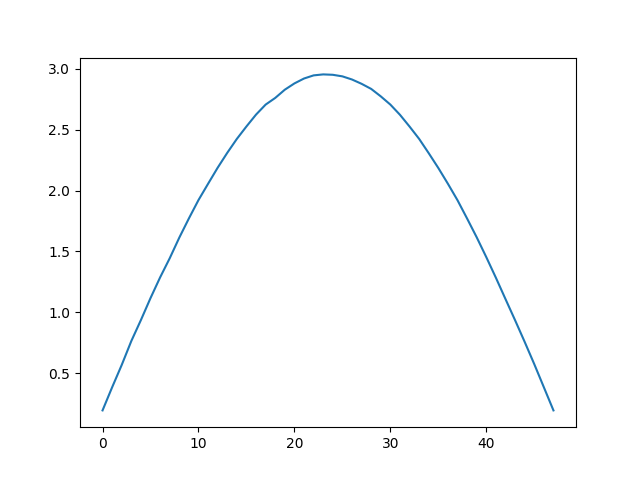

In [16]:
fig, ax = plt.subplots()
ax.plot(laser_curve)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


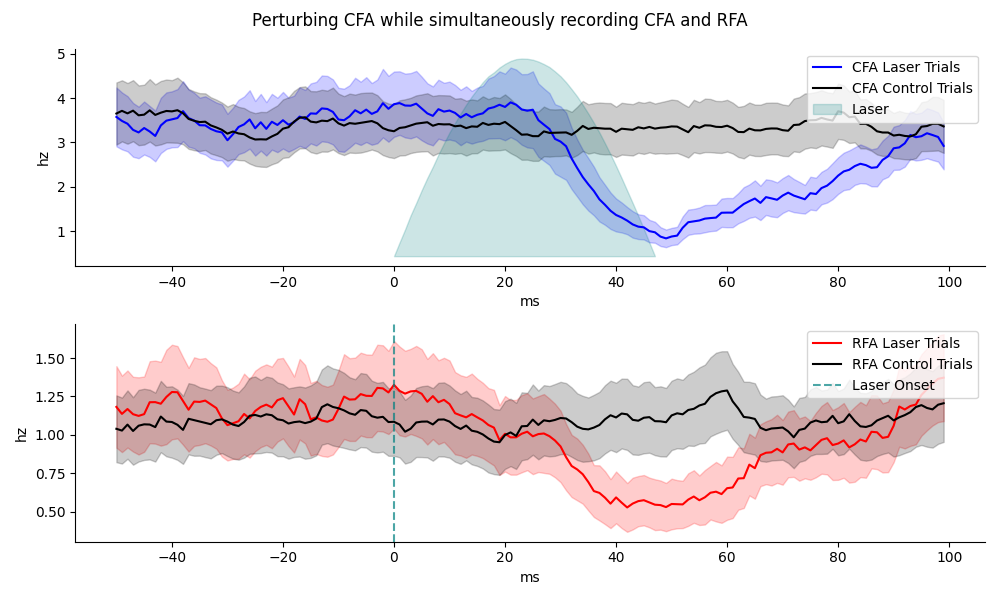

In [17]:
CFA_sts_avgavg = np.average(CFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_b, axis=0)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_b, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_b, axis=0)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(CFA_c, axis=0)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_c, axis=(0,2)) / (fs/1000)
temp = np.average(RFA_c, axis=0)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_neurons) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre

fig1b, ax1b = plt.subplots(2, 1, figsize=(10,6))
ax1b[0].plot(x, CFA_sts_avgavg, color='blue', label='CFA Laser Trials')
ax1b[0].plot(x, CFA_ctrlsts_avgavg, color='black', label = 'CFA Control Trials')
ax1b[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1b[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
cfa_ymin = ax1b[0].get_ylim()[0]
cfa_ymax = ax1b[0].get_ylim()[1]
cfa_laser = normalizeDataToRange(laser_curve, (cfa_ymin, cfa_ymax))
cfa_laser_x = np.arange(0,48)
ax1b[0].fill_between(cfa_laser_x, cfa_ymin, cfa_laser, color='teal', alpha=0.2, label='Laser')
ax1b[0].set_ylabel('hz')
ax1b[0].set_xlabel('ms')
ax1b[0].legend(loc=1)

ax1b[1].plot(x, RFA_sts_avgavg, color='red', label='RFA Laser Trials')
ax1b[1].plot(x, RFA_ctrlsts_avgavg, color='black', label='RFA Control Trials')
ax1b[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1b[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
ax1b[1].axvline(0, color='teal', alpha=0.7, ls='--', label='Laser Onset')
#rfa_ymin = ax1b[1].get_ylim()[0]
#rfa_ymax = ax1b[1].get_ylim()[1]
#rfa_laser = normalizeDataToRange(laser_curve, (rfa_ymin, rfa_ymax))
#rfa_laser_x = np.arange(0,4.8,.1)
#ax1b[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1b[1].legend(loc=1)
ax1b[1].set_xlabel('ms')
ax1b[1].set_ylabel('hz')

ax1b[0].spines['top'].set_visible(False)
ax1b[0].spines['right'].set_visible(False)
ax1b[1].spines['top'].set_visible(False)
ax1b[1].spines['right'].set_visible(False)
fig1b.suptitle('Perturbing CFA while simultaneously recording CFA and RFA')


fig1b.tight_layout()
fig1b.savefig('../results/fig1.pdf')

In [ ]:
f1

# bootstrapping to get error bars

In [4]:
picklepath = '../picklejar/good_model.pickle'
h = pload(picklepath)
#h = h_list[205]

In [5]:
binsize=10
nlags=10

laser_threshold = 2.26
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds = psth_bounds[np.array(session.laser['laser_powers']) > laser_threshold, :]
print(psth_bounds.shape)
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)

(all_nlags_PCA, all_cut_PCA), PCAObjs = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)

(17, 2)


In [6]:
all_laser_nlags, all_laser_cut = session.transformat(PCAObjs, bounds=psth_bounds, binsize=10, nlags=10)
all_laser_cut = all_laser_cut[:, session.num_CFA:]

all_ctrl_nlags, all_ctrl_cut = session.transformat(PCAObjs, bounds=psth_ctrl_bounds, binsize=10, nlags=10)
all_ctrl_cut = all_ctrl_cut[:, session.num_CFA:]

In [7]:
import scipy
def bootstrap_rows(array): 
    nrows = array.shape[0]
    return np.random.choice(nrows, nrows, replace=True)

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return h

In [8]:
num_bootstraps = 100
laser_bootstrap_scores=[]
ctrl_bootstrap_scores=[]

for i in range(num_bootstraps):
    bootstrap_idxs = bootstrap_rows(all_laser_cut)
    bootstrap_X = all_laser_nlags[bootstrap_idxs, :]
    bootstrap_Y = all_laser_cut[bootstrap_idxs, :]
    
    y_pred = test_wiener_filter(bootstrap_X, h)
    y_pred = y_pred[:, session.num_CFA:]
    laser_bootstrap_scores.append(weighted_r2(bootstrap_Y, y_pred))
    
    bootstrap_idxs = bootstrap_rows(all_ctrl_cut)
    bootstrap_X = all_ctrl_nlags[bootstrap_idxs, :]
    bootstrap_Y = all_ctrl_cut[bootstrap_idxs, :]
    
    y_pred = test_wiener_filter(bootstrap_X, h)
    y_pred = y_pred[:, session.num_CFA:]
    ctrl_bootstrap_scores.append(weighted_r2(bootstrap_Y, y_pred))
    
lbs = np.array(laser_bootstrap_scores)
avg_lbs = np.average(lbs)
ci_lbs = mean_confidence_interval(lbs)
sem_lbs = scipy.stats.sem(lbs)
    
cbs = np.array(ctrl_bootstrap_scores)
avg_cbs = np.average(cbs)
ci_cbs = mean_confidence_interval(cbs)
sem_cbs = scipy.stats.sem(cbs)
    
    

/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


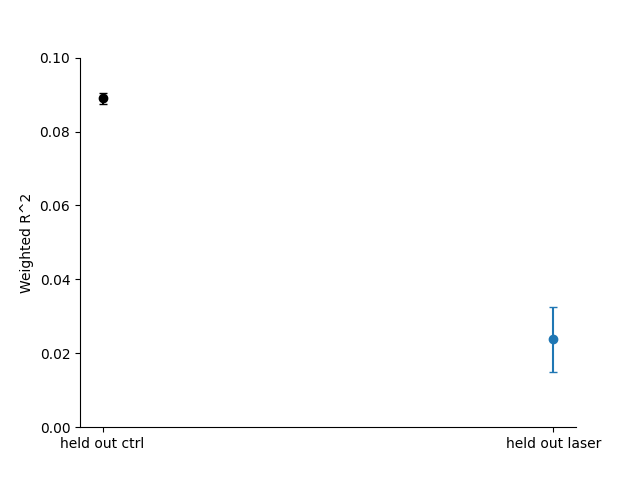

In [20]:
fig, ax = plt.subplots()
#labels = ['ctrl', 'laser']
#Y = [avg_cbs, avg_lbs]
#yerr = [sem_cbs, sem_lbs]
#ax.bar(labels, Y)
#ax.bar('held out ctrl', avg_cbs, color='black', alpha=0.8)
#ax.bar('held out laser', avg_lbs, color='tab:blue', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([0,0.1])
#ax.spines['bottom'].set_visible(False)
#ax.spines['left'].set_visible(False)

ax.errorbar('held out ctrl', avg_cbs, yerr=sem_cbs, ecolor='black', fmt='ko', capsize=3)
ax.errorbar('held out laser', avg_lbs, yerr=sem_lbs, ecolor='tab:blue', fmt='o', markerfacecolor='tab:blue', capsize=3)
ax.set_ylabel('Weighted R^2')

fig.savefig('../results/fig0.pdf')
#ax.set_title('When predicting RFA, model fit on non-perturbed neural data \n has decreased predictivity when generalizing to laser trials')

0.07500219564978394


/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


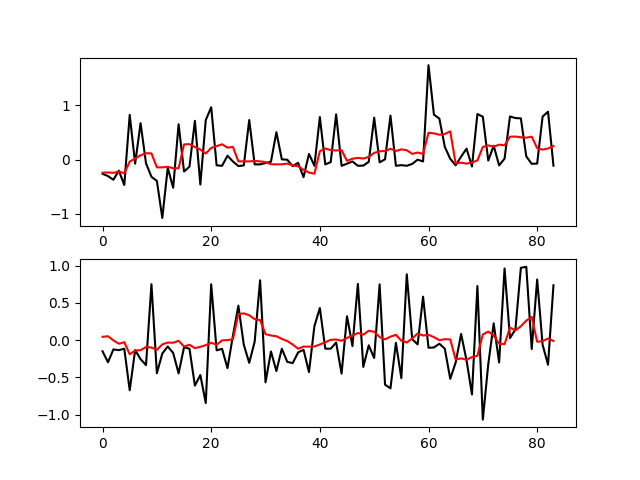

In [10]:
y_pred = test_wiener_filter(all_laser_nlags, h)
y_pred = y_pred[:, session.num_CFA:]


score = weighted_r2(all_laser_cut, y_pred)
fig, ax = plt.subplots(nrows=2)
ax[0].plot(all_laser_cut[:,1], color='black')
ax[0].plot(y_pred[:,1], color='red')
print(weighted_r2(all_laser_cut, y_pred))
y_pred = test_wiener_filter(all_ctrl_nlags, h)
y_pred = y_pred[:, session.num_CFA:]
ax[1].plot(all_ctrl_cut[:all_laser_cut.shape[0],1], color='black')
ax[1].plot(y_pred[:all_laser_cut.shape[0],1], color='red')


In [11]:
picklepath = '../picklejar/RegSweep/h_list_product_10binsize_10lags_logspace6.pickle'
h_list = pload(picklepath)

weights = np.logspace(0, 6, 15)
weight_combos = list(product(weights, weights))

In [12]:
binsize=10
nlags=10

laser_threshold = 2.26
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds = psth_bounds[np.array(session.laser['laser_powers']) > laser_threshold, :]
print(psth_bounds.shape)
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)

(all_nlags_PCA, all_cut_PCA), PCAObjs = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)

(17, 2)


In [13]:
all_laser_nlags, all_laser_cut = session.transformat(PCAObjs, bounds=psth_bounds, binsize=10, nlags=10)
all_laser_cut = all_laser_cut[:, session.num_CFA:]

all_ctrl_nlags, all_ctrl_cut = session.transformat(PCAObjs, bounds=psth_ctrl_bounds, binsize=10, nlags=10)
all_ctrl_cut = all_ctrl_cut[:, session.num_CFA:]

/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


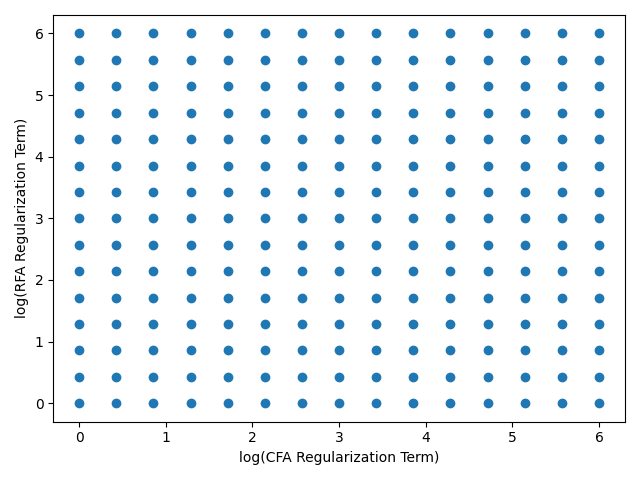

In [14]:
X = np.log10(np.array(weight_combos)[:,0])
Y = np.log10(np.array(weight_combos)[:,1])

fig1, ax1 = plt.subplots()
ax1.scatter(X, Y)
ax1.set_ylabel('log(RFA Regularization Term)')
ax1.set_xlabel('log(CFA Regularization Term)')
fig1.tight_layout()

In [15]:
h_laser_scores = []
h_laser_weights = []

h_ctrl_scores = []
h_ctrl_weights = []
for h in tqdm(h_list):
    y_pred = test_wiener_filter(all_laser_nlags, h)
    y_pred = y_pred[:, session.num_CFA:]
    h_laser_scores.append(weighted_r2(all_laser_cut, y_pred))
    
    h_laser_weights.append(session.weights_per_region(h))
    
    y_pred = test_wiener_filter(all_ctrl_nlags, h)
    y_pred = y_pred[:, session.num_CFA:]
    h_ctrl_scores.append(weighted_r2(all_ctrl_cut, y_pred))
    
    h_ctrl_weights.append(session.weights_per_region(h))
    #temp1, temp2 = relative_input(h, all_nlags_PCA)
    #h_fit_relinputs.append([temp1, temp2])
    #h_fit_scores.append(weighted_r2(all_cut_PCA[:, session.num_CFA:], y_pred[:, session.num_CFA:]))
    
    
h_laser_scores = np.array(h_laser_scores)
h_laser_weights = np.array(h_laser_weights)
h_ctrl_scores = np.array(h_ctrl_scores)
h_ctrl_weights = np.array(h_ctrl_weights)

100%|██████████████████████████████████████████████████████| 225/225 [00:02<00:00, 98.81it/s]


/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


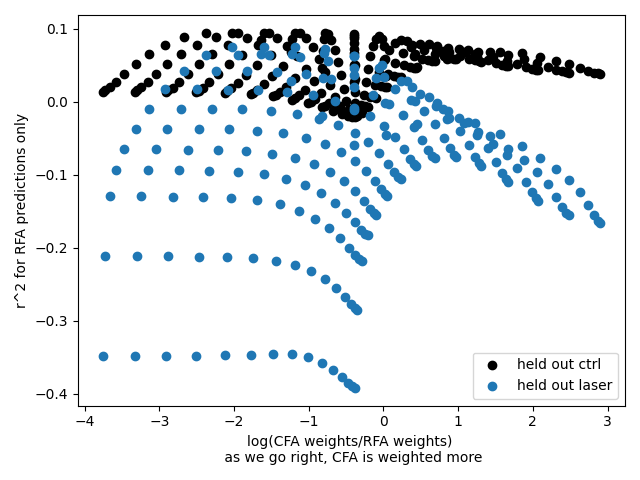

In [16]:
laser_ratio = np.log10(h_laser_weights[:,0] / h_laser_weights[:,1])
ctrl_ratio = np.log10(h_ctrl_weights[:,0] / h_ctrl_weights[:,1])
fig2, ax2 = plt.subplots()
ax2.scatter(ctrl_ratio, h_ctrl_scores, color='black', label='held out ctrl')
ax2.scatter(laser_ratio, h_laser_scores, label='held out laser')
ax2.set_xlabel('log(CFA weights/RFA weights) \n as we go right, CFA is weighted more')
ax2.set_ylabel('r^2 for RFA predictions only')
ax2.legend()

fig2.tight_layout()

In [17]:
nada, bin_ratio_edges = np.histogram(laser_ratio, bins=15)

h_laser_scores_keep = []
laser_ratio_keep = []

h_ctrl_scores_keep = []
ctrl_ratio_keep = []

good_regs = []
weight_combos = np.array(weight_combos)

h_model_keep = []
h_array = np.array(h_list)

for i in range(bin_ratio_edges.size - 1):
    condition1 = laser_ratio > bin_ratio_edges[i]
    condition2 = laser_ratio < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(h_laser_scores[indices])
    temp1 = h_laser_scores[indices]
    temp2 = temp1[keep]
    #print(temp2)
    #print(indices, keep)
    
    h_laser_scores_keep.append(temp2)
    
    temp1 = laser_ratio[indices]
    temp2 = temp1[keep]
    laser_ratio_keep.append(temp2)
    
    temp1 = weight_combos[indices]
    temp2 = temp1[keep]
    good_regs.append(temp2)
    
    #condition1 = ctrl_ratio > bin_ratio_edges[i]
    #condition2 = ctrl_ratio < bin_ratio_edges[i+1]
    #indices = np.argwhere(np.logical_and(condition1,condition2))
    #keep = np.argmax(h_ctrl_scores[indices])
    temp1 = h_ctrl_scores[indices]
    temp2 = temp1[keep]
    
    h_ctrl_scores_keep.append(temp2)
    
    temp1 = ctrl_ratio[indices]
    temp2 = temp1[keep]
    ctrl_ratio_keep.append(temp2)
    
    temp1 = h_array[indices,:,:]
    temp1 = np.squeeze(temp1)
    temp2 = temp1[keep,:,:]
    h_model_keep.append(temp2)
    
    

/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)
/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


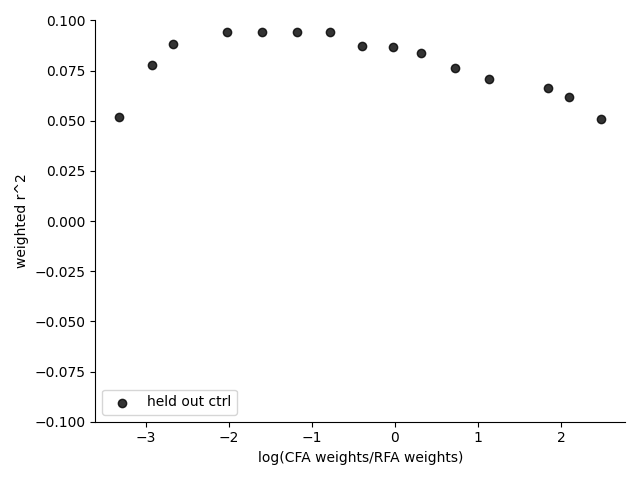

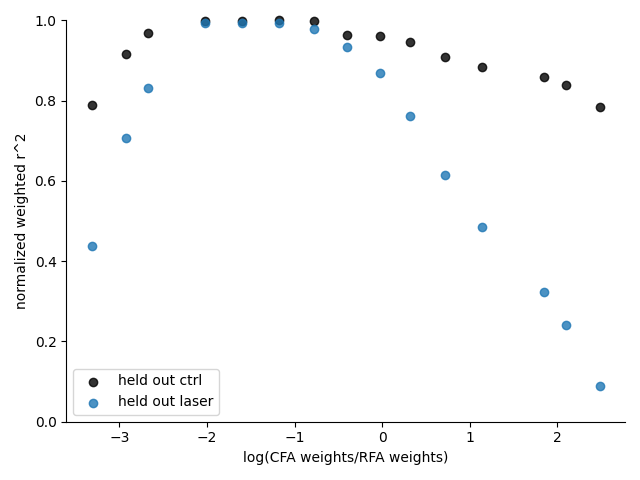

In [32]:
fig3, ax3 = plt.subplots()
maximum = max(h_ctrl_scores_keep)
minimum = min(h_laser_scores_keep)

norm_ctrl = ((h_ctrl_scores_keep - minimum) / (maximum-minimum))
norm_laser = ((h_laser_scores_keep - minimum) / (maximum-minimum))
shift = max(norm_ctrl) - max(norm_laser)

ax3.scatter(ctrl_ratio_keep, h_ctrl_scores_keep, color='black', label='held out ctrl', alpha=0.8)
ax3.set_ylim([-.1, .1])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.legend(loc='lower left')
ax3.set_xlabel('log(CFA weights/RFA weights)')
ax3.set_ylabel('weighted r^2')
#ax3.scatter(laser_ratio_keep, norm_laser + (shift-0.005), label='held out laser', alpha=0.8)
#ax3.set_title('Wide range of CFA/RFA weights have comparable predictivity on RFA control trials')

fig4, ax4, = plt.subplots()
ax4.scatter(ctrl_ratio_keep, norm_ctrl, color='black', label='held out ctrl', alpha=0.8, clip_on=False)
ax4.scatter(laser_ratio_keep, norm_laser+shift-0.005, label='held out laser', alpha=0.8, clip_on=False)
ax4.set_ylim([0, 1])
#ax4.set_title('A narrower range of CFA/RFA weights have \n peak predictivity on pertubation trials')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_xlabel('log(CFA weights/RFA weights)')
ax4.set_ylabel('normalized weighted r^2')
ax4.legend(loc='lower left')


fig3.tight_layout()
fig4.tight_layout()
fig3.savefig('../results/fig3.pdf')
fig4.savefig('../results/fig4.pdf')

In [213]:
picklepath='../picklejar/LaserSWSweep/goodreg_output.pickle'
output= pload(picklepath)

In [217]:
reg_laser_scores = []
reg_ctrl_scores = []
reg_weights = []
for o in output:
    reg_laser_scores.append(o[1])
    reg_ctrl_scores.append(o[2])
    reg_weights.append(session.weights_per_region(o[3]))

reg_laser_scores = np.array(reg_laser_scores)
reg_ctrl_scores = np.array(reg_ctrl_scores)
reg_weights = np.array(reg_weights)
weight_ratios = np.log10(reg_weights[:,0] / reg_weights[:,1])

/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


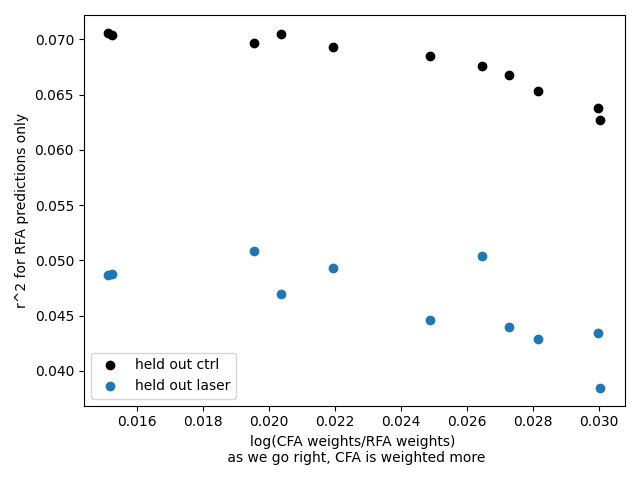

In [218]:
fig6, ax6 = plt.subplots()
ax6.scatter(weight_ratios, reg_ctrl_scores, color='black', label='held out ctrl')
ax6.scatter(weight_ratios, reg_laser_scores, label='held out laser')
ax6.set_xlabel('log(CFA weights/RFA weights) \n as we go right, CFA is weighted more')
ax6.set_ylabel('r^2 for RFA predictions only')
ax6.legend()

fig6.tight_layout()

In [28]:
temp = np.argsort(reg_laser_scores)

In [31]:
weight_combos[temp[-1]]

(31622.776601683792, 31622.776601683792)

In [32]:
weight_combos[temp[-2]]

(1000000.0, 31622.776601683792)

In [33]:
weight_combos[temp[-3]]

(1000000.0, 1000.0)

In [38]:
picklepath = '../picklejar/RegSweep/h_list_product_10binsize_10lags_logspace6.pickle'
h_list = pload(picklepath)

weights = np.logspace(0, 6, 15)
weight_combos = list(product(weights, weights))